In [1]:
# ================================================================
# Manager clustering over the full dataset (features + PCA + KMeans)
# ================================================================
from pathlib import Path
import re
import numpy as np
import pandas as pd
import networkx as nx

# ---- sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# ---- optional SciPy for Leontief
try:
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False


In [2]:
# ------------------ Config ------------------
EDGES = Path("../../WRDS/financed_emissions_network_final_plus_manual_fuzzy.csv")
PR_ALPHA = 0.60  # the alpha you documented

# ------------------ Helpers ------------------
def norm_name(s: str) -> str:
    if not isinstance(s, str): s = "" if s is None else str(s)
    s = s.upper().replace("&"," AND ")
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def is_fundlike(name: str) -> bool:
    FUND_WORDS = ("ETF","FUND","TRUST","INDEX","UCITS","ETN","ETFS","PORTFOLIO",
                  "TOTAL RETURN","TREASUR","BOND","DIVIDEND","INCOME","BETA",
                  "BETABUILDERS","MARKETBETA","ACCESS","SHARES","SPDR",
                  "ISHARES","VANGUARD","SCHWAB","MUTUAL","EXCHANGE TRADED")
    REIT_HINTS = ("REALTY TRUST","PROPERTIES","PROPERTY","REIT")
    s = str(name).upper()
    if any(h in s for h in REIT_HINTS): return False
    return any(w in s for w in FUND_WORDS)

def build_graphs_and_metrics(df: pd.DataFrame):
    """Returns (G_inv, G_cf, direct_mgr) and sets PR & Leontief masses on G_cf."""
    # Direct graph: manager -> stock (weight = own_frac)
    G_inv = nx.DiGraph()
    for _, r in df.iterrows():
        u, v, w = r["_manager_key"], r["_company_key"], float(r["own_frac"])
        if u and v and u != v and w > 0:
            G_inv.add_edge(u, v, w=w, fe_edge=r["fe_edge"])
            G_inv.nodes[v]["s12"] = float(r["scope12"])

    # Carbon-flow graph: stock -> manager
    G_cf = nx.DiGraph()
    for n, d in G_inv.nodes(data=True):
        G_cf.add_node(n, **d)
    for u, v, d in G_inv.edges(data=True):
        G_cf.add_edge(v, u, w=d.get("w", 0.0), fe_edge=d.get("fe_edge", 0.0))

    # Roles + direct_fe
    investors = set(df["_manager_key"])
    investees = set(df["_company_key"])
    roles = {}
    for n in G_cf.nodes():
        r_inv = n in investors
        r_iss = n in investees
        roles[n] = "both" if (r_inv and r_iss) else ("investor" if r_inv else "investee")
    nx.set_node_attributes(G_cf, roles, "role")
    nx.set_node_attributes(G_inv, roles, "role")
    direct_mgr = df.groupby("_manager_key")["fe_edge"].sum().rename("direct_fe")
    nx.set_node_attributes(G_cf, direct_mgr.to_dict(), "direct_fe")
    nx.set_node_attributes(G_inv, direct_mgr.to_dict(), "direct_fe")

    # Anchored PageRank on issuer layer; mass = distributable issuer emissions
    in_owned = {n: min(1.0, sum(G_cf[p][n].get("w", 0.0) for p in G_cf.predecessors(n))) for n in G_cf.nodes()}
    distributable = pd.Series({n: float(G_cf.nodes[n].get("s12", 0.0)) for n in G_cf.nodes()})
    s = (distributable * pd.Series(in_owned)).fillna(0.0)
    S = float(s.sum())
    personalization = (s / S).to_dict() if S > 0 else None
    pr = nx.pagerank(G_cf, alpha=PR_ALPHA, weight="w", personalization=personalization)
    pr_mass = {n: pr.get(n, 0.0) * S for n in G_cf.nodes()}
    nx.set_node_attributes(G_cf, pr_mass, "indirect_fe")

    # Leontief (solve (I - A^T) y = s)
    nodes = list(G_cf.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    nN = len(nodes)
    rows, cols, data = [], [], []
    for u, v, d in G_cf.edges(data=True):
        w = float(d.get("w", 0.0))
        if w > 0 and u in idx and v in idx and u != v:
            rows.append(idx[v]); cols.append(idx[u]); data.append(w)

    if HAVE_SCIPY:
        AT = sp.csr_matrix((data, (rows, cols)), shape=(nN, nN))
        col_sums = np.asarray(AT.sum(axis=0)).ravel()
        cap = 0.999
        scale = np.ones_like(col_sums)
        mask = col_sums > cap
        scale[mask] = cap / col_sums[mask]
        if mask.any():
            AT = AT @ sp.diags(scale)
        I = sp.eye(nN, format="csr")
        s_vec = np.array([float(s.get(nm, 0.0)) for nm in nodes])
        M = (I - AT) + 1e-9 * I
        try:
            y = spla.spsolve(M, s_vec)
        except Exception:
            y, info = spla.gmres(M, s_vec, tol=1e-8, restart=200, maxiter=500)
            if info != 0:
                y = np.linalg.solve(M.toarray(), s_vec)
    else:
        AT = np.zeros((nN, nN), dtype=float)
        for r, c, w in zip(rows, cols, data):
            AT[r, c] = w
        col_sums = AT.sum(axis=0)
        cap = 0.999
        scale = np.ones_like(col_sums)
        mask = col_sums > cap
        scale[mask] = cap / col_sums[mask]
        AT = AT * scale
        s_vec = np.array([float(s.get(nm, 0.0)) for nm in nodes])
        M = (np.eye(nN) - AT) + 1e-9 * np.eye(nN)
        y = np.linalg.solve(M, s_vec)

    y = np.maximum(y, 0.0)
    nx.set_node_attributes(G_cf, {nodes[i]: float(y[i]) for i in range(nN)}, "leontief_fe")
    return G_inv, G_cf, direct_mgr

def build_manager_features(df: pd.DataFrame, G_cf: nx.DiGraph, direct_mgr: pd.Series):
    """Return a manager-level features DataFrame."""
    managers = sorted(set(df["_manager_key"]))
    feats = []
    for m in managers:
        holdings = df.loc[df["_manager_key"] == m, ["_company_key","own_frac","fe_edge","scope12"]]
        if holdings.empty:
            continue
        total_direct = float(direct_mgr.get(m, 0.0))
        total_pr     = float(G_cf.nodes.get(m, {}).get("indirect_fe", 0.0))
        total_leo    = float(G_cf.nodes.get(m, {}).get("leontief_fe", 0.0))

        # Diversification / ownership structure
        n_hold = int(len(holdings))
        w_sum  = float(holdings["own_frac"].sum())
        hhi = float(((holdings["own_frac"] / w_sum) ** 2).sum()) if w_sum > 0 else 0.0
        avg_own = float(holdings["own_frac"].mean())

        # Concentration of financed emissions along edges
        fe = holdings["fe_edge"].to_numpy()
        fe_tot = fe.sum() if fe.size else 0.0
        fe_top10 = np.sort(fe)[-10:].sum() if fe.size else 0.0
        fe_top10_share = float(fe_top10/fe_tot) if fe_tot>0 else 0.0

        # Graph stats on carbon-flow (stock->manager)
        in_deg_cnt = G_cf.in_degree(m)
        in_strength = float(sum(G_cf[u][m].get("w", 0.0) for u in G_cf.predecessors(m)))

        feats.append({
            "manager": m,
            "direct_fe": total_direct,
            "indirect_fe_pr": total_pr,
            "leontief_fe": total_leo,
            "ret_pr": (total_pr / total_direct) if total_direct > 0 else 0.0,
            "ret_leo": (total_leo / total_direct) if total_direct > 0 else 0.0,
            "n_holdings": n_hold,
            "own_sum": w_sum,
            "own_hhi": hhi,
            "own_avg": avg_own,
            "fe_top10_share": fe_top10_share,
            "in_deg_cnt": in_deg_cnt,
            "in_strength": in_strength,
        })
    return pd.DataFrame(feats)


In [3]:
# ============= Load / prepare data (idempotent) =============
if 'df' in globals() and isinstance(df, pd.DataFrame) and not df.empty:
    print(f"Reusing existing df with {len(df):,} rows; skipping read_csv.")
else:
    df0 = pd.read_csv(EDGES, low_memory=False)
    df0["_manager_key"] = df0["manager"].astype(str).map(norm_name)
    df0["_company_key"] = df0["stock"].astype(str).map(norm_name)
    df0["is_fundlike"]  = df0["stock"].astype(str).map(is_fundlike)
    df0["ownership"] = pd.to_numeric(df0["ownership"], errors="coerce")
    df0["scope12"]   = pd.to_numeric(df0["scope12_total_tco2"], errors="coerce")
    df = df0.loc[df0["ownership"].notna() & df0["scope12"].notna()].copy()
    df = df.loc[~df["is_fundlike"]].copy()
    df["own_frac"] = (df["ownership"]/100.0).clip(lower=0.0)
    df["fe_edge"]  = df["own_frac"] * df["scope12"]

# Build graphs + metrics if missing
if 'G_cf' not in globals() or 'G_inv' not in globals() or 'direct_mgr' not in globals():
    G_inv, G_cf, direct_mgr = build_graphs_and_metrics(df)

# ============= Feature matrix =============
mgr_feats = build_manager_features(df, G_cf, direct_mgr).set_index("manager").sort_index()
mgr_feats = mgr_feats.loc[mgr_feats["direct_fe"] > 0].copy()  # drop zero-direct edge case

# Log-transform skewed totals (safe log1p)
for c in ["direct_fe","indirect_fe_pr","leontief_fe","own_sum","in_strength"]:
    mgr_feats[f"log1p_{c}"] = np.log1p(mgr_feats[c].astype(float))

# Choose features
feature_cols = [
    "ret_pr","ret_leo",
    "n_holdings","own_avg","own_hhi","fe_top10_share",
    "log1p_direct_fe","log1p_indirect_fe_pr","log1p_leontief_fe",
    "in_deg_cnt","log1p_in_strength"
]
X = mgr_feats[feature_cols].fillna(0.0).astype(float).values



In [10]:
# ============= Scale, reduce, cluster =============
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# PCA (keep enough variance, cap at 10 components)
pca = PCA(n_components=min(10, Xz.shape[1]), random_state=42)
Xp = pca.fit_transform(Xz)
explained = pca.explained_variance_ratio_.sum()

# Choose K via silhouette on a small grid; subsample if very large
rng = np.random.default_rng(42)
def silhouette_for_k(k):
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=512, n_init="auto")
    labels = km.fit_predict(Xp)
    if Xp.shape[0] > 1500:
        idx = rng.choice(Xp.shape[0], 1500, replace=False)
        return silhouette_score(Xp[idx], labels[idx])
    return silhouette_score(Xp, labels)

candidate_K = [3,4,5,6,7,8]
sil_scores = []
for k in candidate_K:
    try:
        sil_scores.append((k, silhouette_for_k(k)))
    except Exception:
        sil_scores.append((k, np.nan))

sil_df = pd.DataFrame(sil_scores, columns=["K","silhouette"]).dropna().sort_values("silhouette", ascending=False)
best_K = int(sil_df.iloc[0]["K"]) if not sil_df.empty else 5

km = MiniBatchKMeans(n_clusters=best_K, random_state=42, batch_size=512, n_init="auto")
labels = km.fit_predict(Xp)

# ============= Outputs & profiling =============
mgr_out = mgr_feats.copy()
mgr_out["cluster"] = labels
mgr_out["pca1"] = Xp[:,0]
mgr_out["pca2"] = Xp[:,1]
mgr_out["pca_var_explained_sum"] = explained

# Cluster profile (medians for interpretability)
profile_cols = [
    "direct_fe","indirect_fe_pr","leontief_fe","ret_pr","ret_leo",
    "n_holdings","own_avg","own_hhi","fe_top10_share","in_deg_cnt","in_strength"
]
cluster_profile = mgr_out.groupby("cluster")[profile_cols].median().sort_index()

print("\n=== Chosen K and silhouette (descending) ===")
print(sil_df)
print(f"\nSelected K = {best_K}; PCA variance explained (sum) = {explained:.2f}")

print("\n=== Cluster sizes ===")
print(mgr_out["cluster"].value_counts().sort_index())

print("\n=== Cluster medians (interpretation guide) ===")
print(cluster_profile)

# Save for downstream analysis
mgr_out.reset_index().rename(columns={"index":"manager"}).to_csv("manager_clusters.csv", index=False)
cluster_profile.to_csv("manager_cluster_profile.csv")
print("\nWrote: manager_clusters.csv and manager_cluster_profile.csv")


=== Chosen K and silhouette (descending) ===
   K  silhouette
1  4    0.285527
2  5    0.278146
0  3    0.273617
3  6    0.238015
5  8    0.233819
4  7    0.206249

Selected K = 4; PCA variance explained (sum) = 1.00

=== Cluster sizes ===
cluster
0     756
1    3477
2     903
3    2139
Name: count, dtype: int64

=== Cluster medians (interpretation guide) ===
            direct_fe  indirect_fe_pr  leontief_fe    ret_pr   ret_leo  \
cluster                                                                  
0        96360.510713     1070.324625  2030.066523  0.014100  0.026482   
1         4434.326657       70.166480   134.236247  0.018612  0.034801   
2          395.580603        6.320325    12.205148  0.014313  0.027843   
3          658.299886        0.444367     1.043842  0.000515  0.001085   

         n_holdings   own_avg   own_hhi  fe_top10_share  in_deg_cnt  \
cluster                                                               
0            1251.0  0.000739  0.015818        0.5

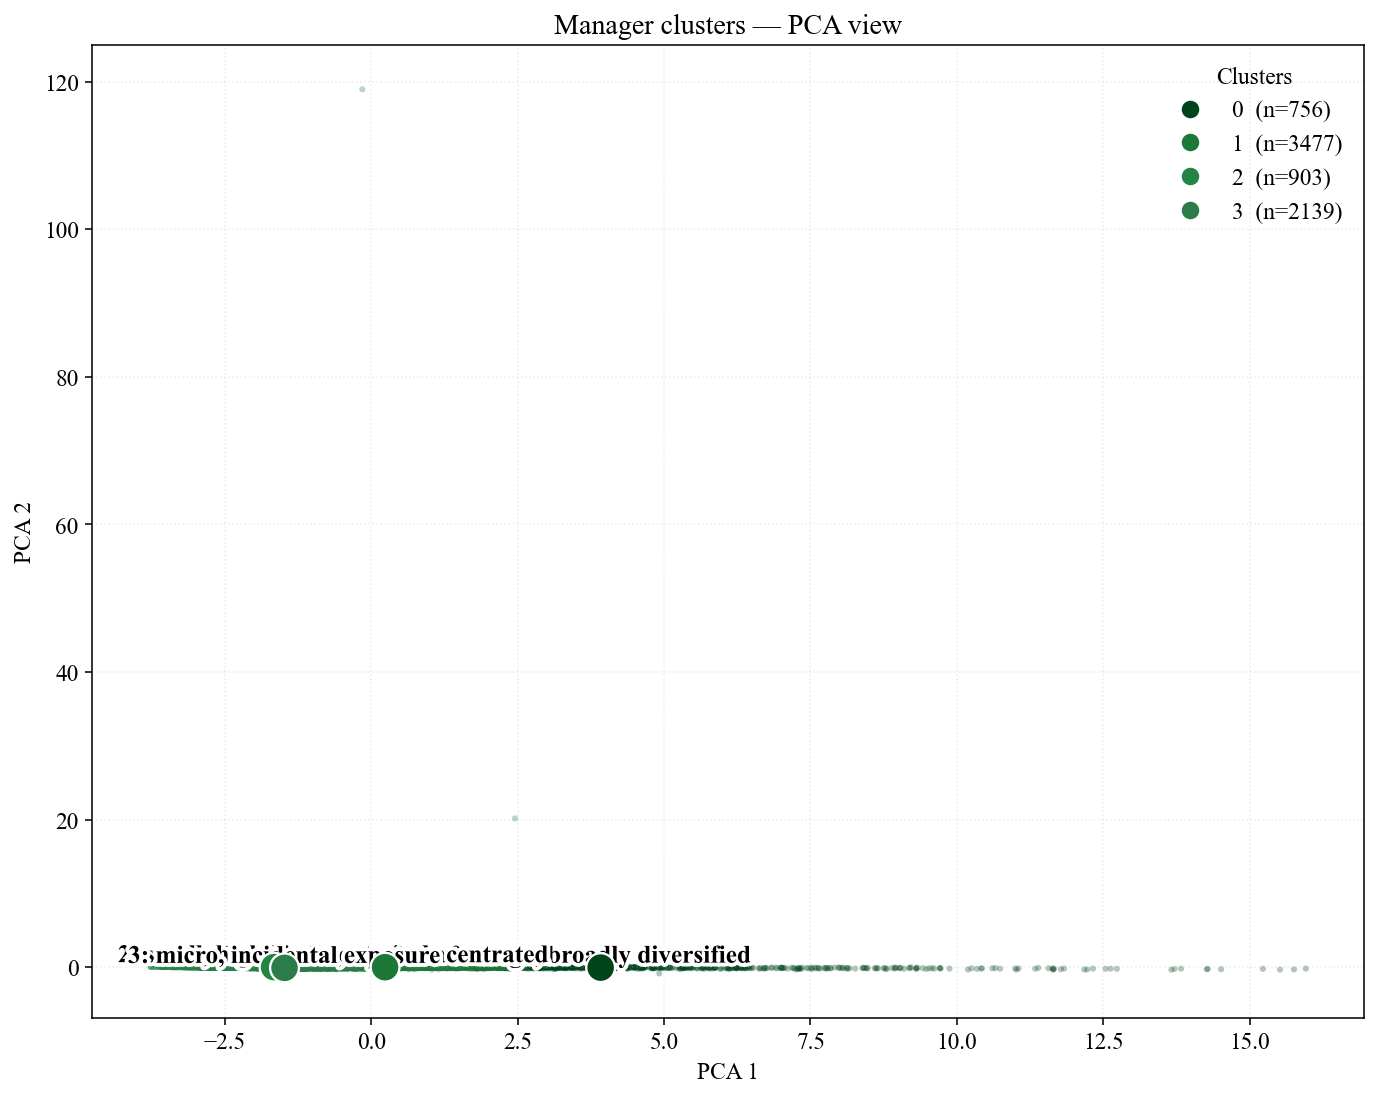

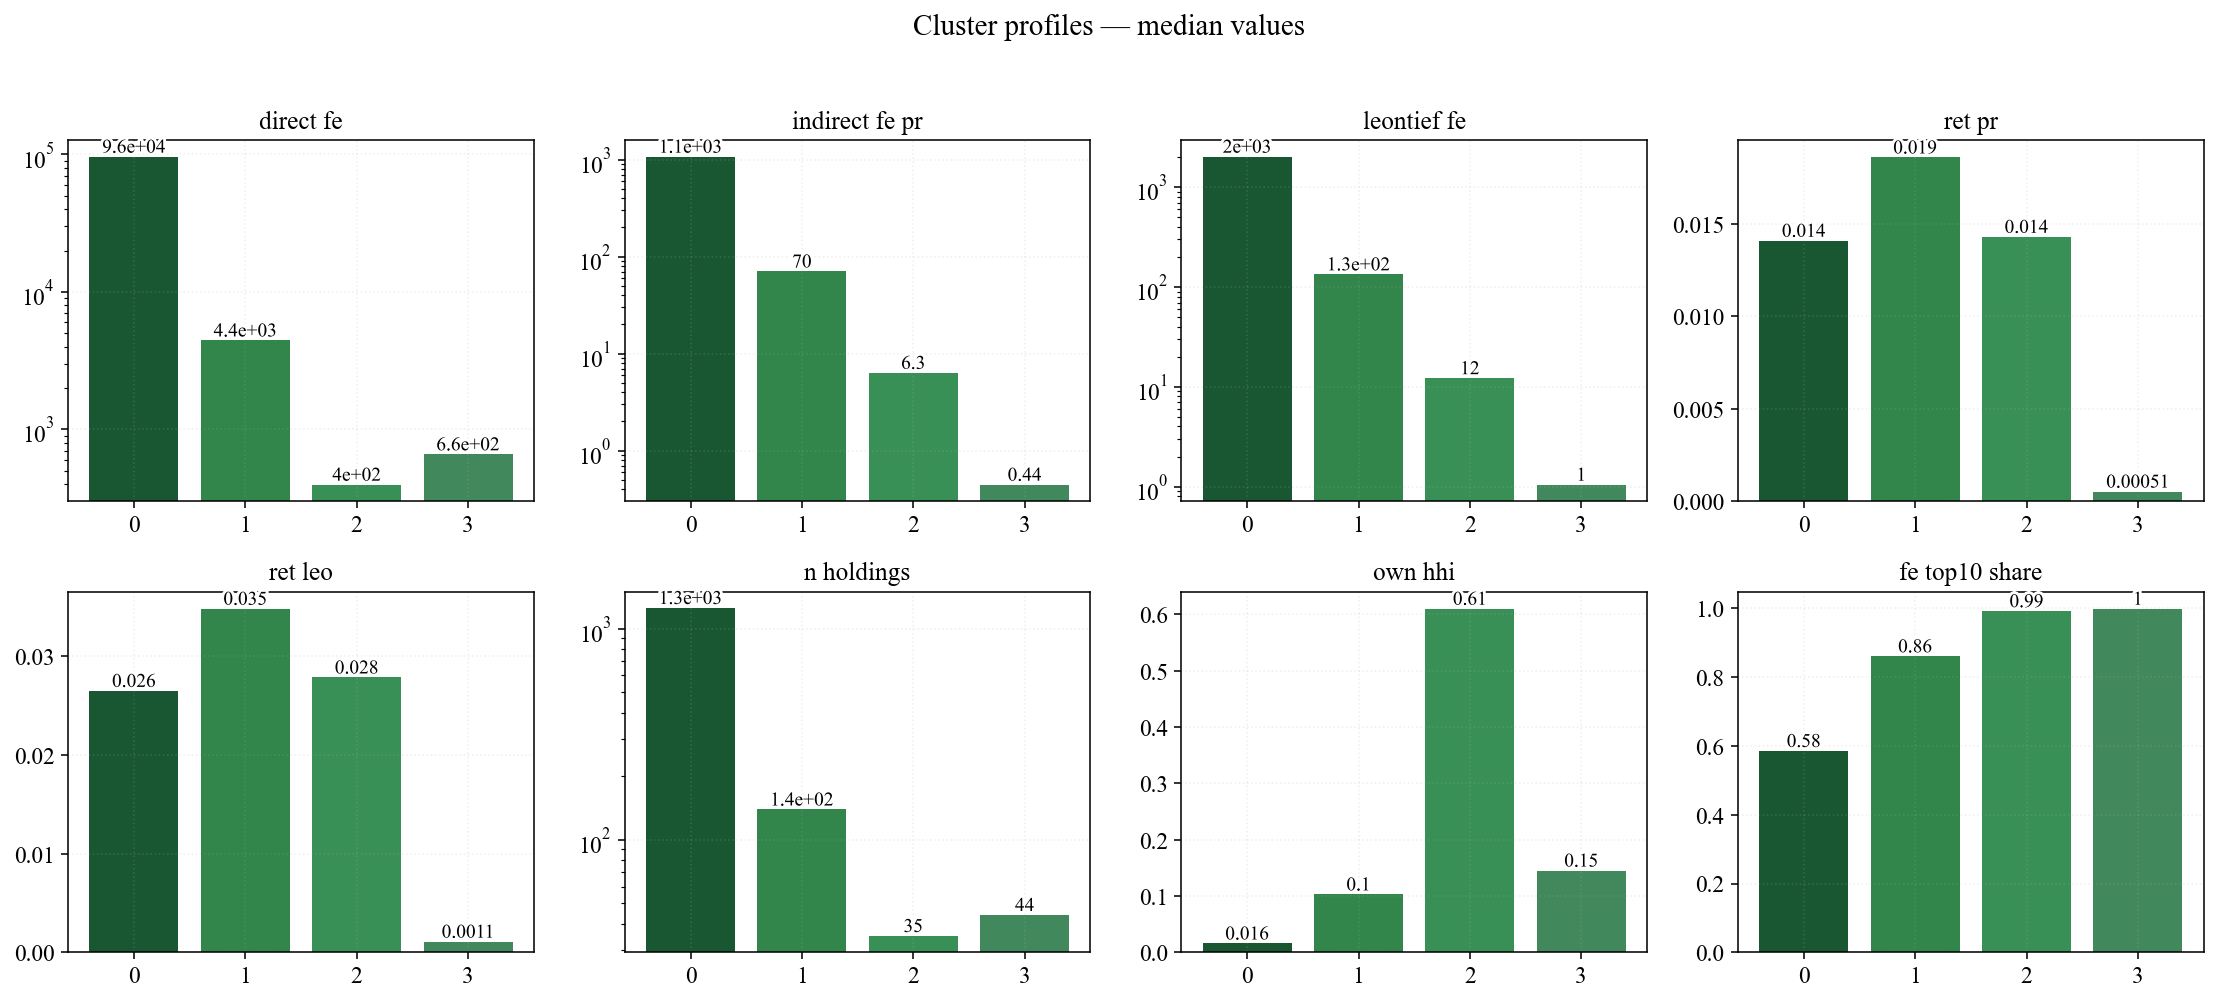

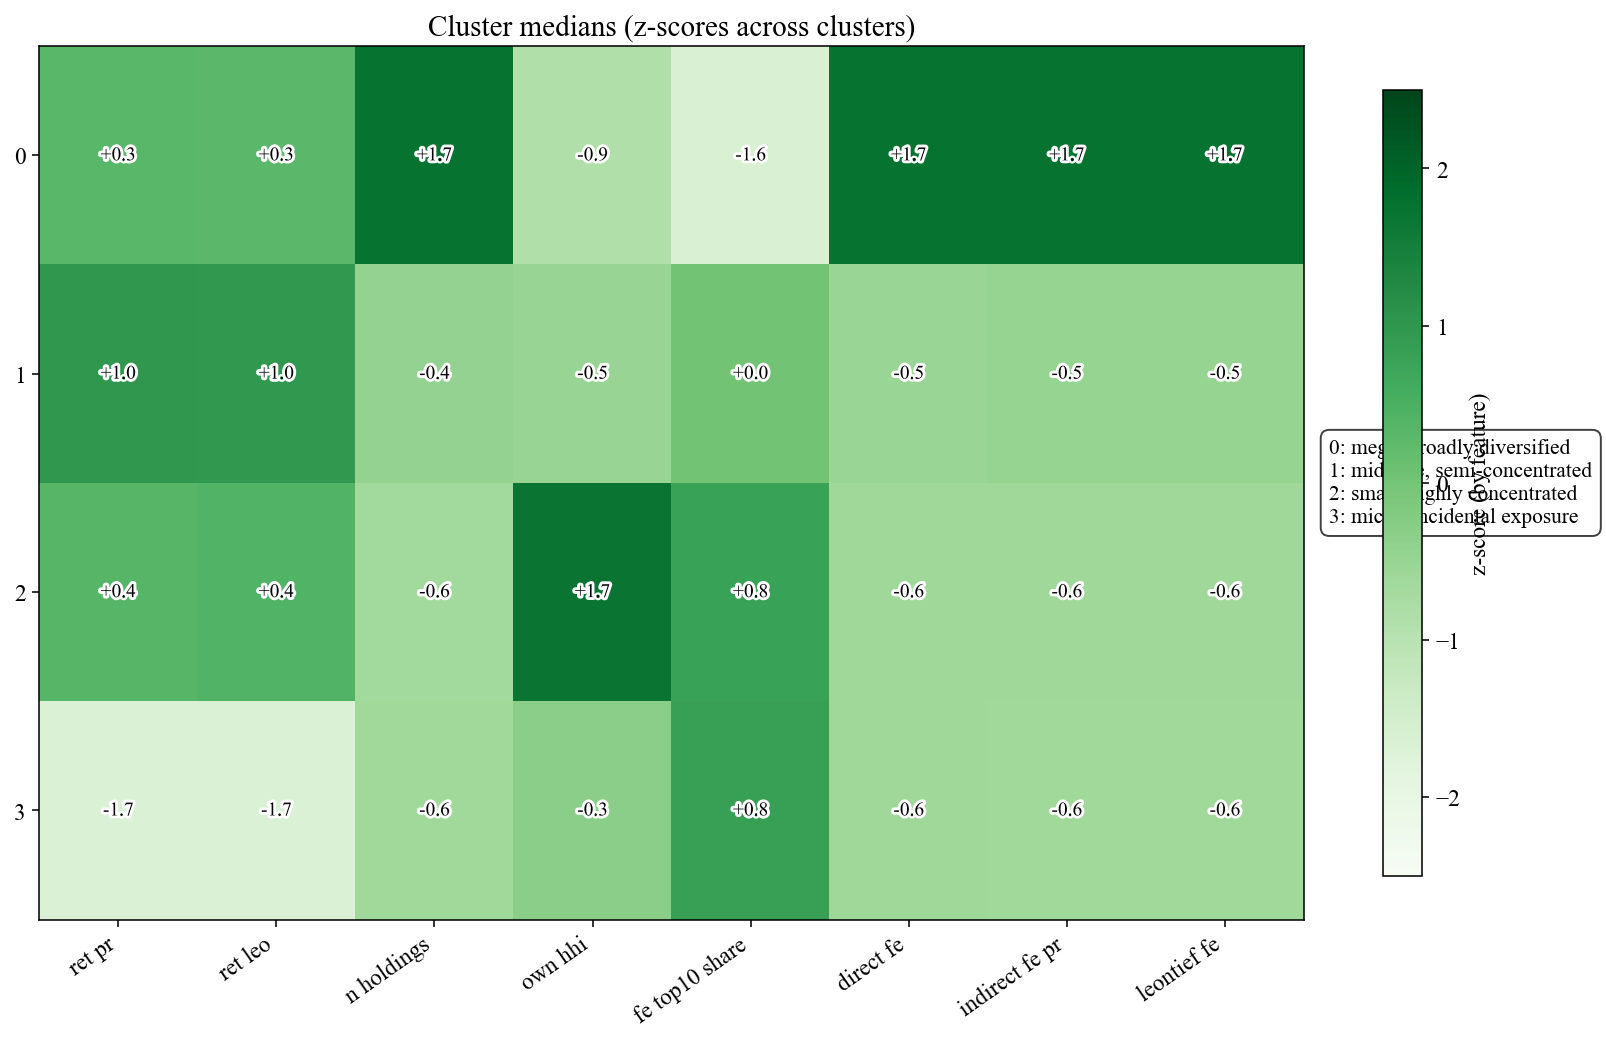

In [13]:
# =========================
# Visualizing manager clusters (ALL-GREEN PALETTE)
# =========================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib as mpl
from matplotlib.colors import ListedColormap, Normalize

# ---- style: Times, larger labels, white halo for annotations
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12

# ---- load data (prefer in-memory, else CSVs)
if 'mgr_out' in globals() and isinstance(mgr_out, pd.DataFrame) and not mgr_out.empty:
    _mgr = mgr_out.copy()
else:
    _mgr = pd.read_csv("manager_clusters.csv")

if 'cluster_profile' in globals() and isinstance(cluster_profile, pd.DataFrame) and not cluster_profile.empty:
    _prof = cluster_profile.copy()
else:
    _prof = pd.read_csv("manager_cluster_profile.csv", index_col=0)

# ---- basic sanity
assert {"cluster","pca1","pca2"}.issubset(_mgr.columns), "Expected columns not found in manager_clusters.csv"
clusters = sorted(_mgr["cluster"].unique().tolist())
K = len(clusters)

# ---- GREEN palette (qualitative, high contrast; supports many clusters)
# Dark → light sequence with perceptible steps (no blue tints)
green_palette = [
    "#00441B", "#1B7837", "#238443", "#2C7C4A", "#31824B",
    "#3A9957", "#41AB5D", "#55B567", "#66C679", "#78C679",
    "#8ED08A", "#A1D99B", "#ADDD8E", "#BFE6A8", "#D0EDBF"
]
# Ensure we can cover arbitrary K
def get_green_color(i):
    return green_palette[i % len(green_palette)]

cluster_colors = {c: get_green_color(i) for i, c in enumerate(clusters)}

# ---- human-friendly names (for K=4 we map your narrative; otherwise generic)
default_names = {c: f"cluster {c}" for c in clusters}
if K == 4:
    default_names = {
        0: "mega, broadly diversified",
        1: "mid-size, semi-concentrated",
        2: "small, highly concentrated",
        3: "micro, incidental exposure",
    }
cluster_names = {c: default_names.get(c, f"cluster {c}") for c in clusters}

# ---- compute centroids in PCA space
centroids = _mgr.groupby("cluster")[["pca1","pca2"]].median()

# =========================================
# 1) PCA scatter with centroids + labels
# =========================================
fig, ax = plt.subplots(figsize=(10,8), dpi=140)

# scatter (alpha to reduce overplot)
for c in clusters:
    mask = _mgr["cluster"] == c
    ax.scatter(_mgr.loc[mask,"pca1"], _mgr.loc[mask,"pca2"],
               s=10, alpha=0.30, label=f"{c}: {cluster_names[c]}",
               color=cluster_colors[c], edgecolors='none')

# centroids
ax.scatter(centroids["pca1"], centroids["pca2"],
           s=220, color=[cluster_colors[c] for c in centroids.index],
           edgecolor="white", linewidth=1.2, zorder=5)

# annotate centroids (white halo for legibility)
for c, (x, y) in centroids.iterrows():
    txt = ax.text(x, y, f"{c}: {cluster_names[c]}",
                  fontsize=13, weight="bold", ha="center", va="bottom")
    txt.set_path_effects([pe.withStroke(linewidth=4, foreground="white")])

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("Manager clusters — PCA view")
ax.grid(alpha=0.25, linestyle=":")
# Legend: show sizes per cluster
sizes = _mgr["cluster"].value_counts().sort_index()
legend_lines = [mpl.lines.Line2D([0],[0], marker='o', linestyle='',
                                 color=cluster_colors[c], label=f"{c}  (n={sizes.get(c,0)})",
                                 markersize=8) for c in clusters]
leg = ax.legend(handles=legend_lines, frameon=False, loc="best", title="Clusters")
plt.tight_layout()
plt.show()

# =====================================================
# 2) Small-multiples profile of cluster medians (green bars)
# =====================================================
# pick a compact set of interpretable features
profile_cols = [
    "direct_fe","indirect_fe_pr","leontief_fe",
    "ret_pr","ret_leo",
    "n_holdings","own_hhi","fe_top10_share"
]
prof = _prof[profile_cols].copy()

# tidy helpers for axes
def _format_axis(ax, title):
    ax.set_title(title, fontsize=13)
    ax.grid(alpha=0.2, linestyle=':')

fig, axes = plt.subplots(2, 4, figsize=(16,7), dpi=140)
axes = axes.ravel()

# A few features benefit from log scale due to skew
log_scale_cols = {"direct_fe", "indirect_fe_pr", "leontief_fe", "n_holdings"}

for i, col in enumerate(profile_cols):
    ax = axes[i]
    vals = prof[col].reindex(clusters)  # ensure consistent order
    bars = ax.bar(range(K), vals.values, color=[cluster_colors[c] for c in clusters], alpha=0.90)
    ax.set_xticks(range(K))
    ax.set_xticklabels([f"{c}" for c in clusters])
    if col in log_scale_cols:
        ax.set_yscale("log")
    _format_axis(ax, col.replace("_"," "))
    # annotate medians
    for j, b in enumerate(bars):
        y = b.get_height()
        if np.isfinite(y) and y > 0:
            txt = ax.text(b.get_x()+b.get_width()/2, y, f"{y:.2g}",
                          ha="center", va="bottom", fontsize=10)
            txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

plt.suptitle("Cluster profiles — median values", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# =========================================
# 3) Heatmap of z-scored cluster medians (green gradient)
# =========================================
from sklearn.preprocessing import StandardScaler

feat_for_heat = [
    "ret_pr","ret_leo",
    "n_holdings","own_hhi","fe_top10_share",
    "direct_fe","indirect_fe_pr","leontief_fe"
]
H = _prof[feat_for_heat].reindex(clusters)  # K x F

# z-score by column (across clusters) to show relative highs/lows
scaler = StandardScaler(with_mean=True, with_std=True)
H_z = pd.DataFrame(scaler.fit_transform(H.values),
                   index=H.index, columns=H.columns)

fig, ax = plt.subplots(figsize=(12, 0.7*len(feat_for_heat)+2), dpi=140)

# Use a pure green colormap; negatives will be very light, positives dark green
greens_cmap = plt.cm.Greens
im = ax.imshow(H_z.values, cmap=greens_cmap, aspect="auto", vmin=-2.5, vmax=2.5)

# ticks/labels
ax.set_yticks(range(K)); ax.set_yticklabels([f"{c}" for c in clusters])
ax.set_xticks(range(len(feat_for_heat))); ax.set_xticklabels([c.replace("_"," ") for c in feat_for_heat],
                                                             rotation=35, ha="right")
ax.set_title("Cluster medians (z-scores across clusters)", fontsize=15)

# annotate cells with signs
for i in range(K):
    for j in range(len(feat_for_heat)):
        val = H_z.iloc[i, j]
        s = f"{val:+.1f}"
        txt = ax.text(j, i, s, ha="center", va="center", fontsize=10, color="black")
        txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

cbar = plt.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("z-score (by feature)")

# right-hand legend with names
legend_text = "\n".join([f"{c}: {cluster_names[c]}" for c in clusters])
bbox_props = dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.75)
ax.text(1.02, 0.5, legend_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', bbox=bbox_props)

plt.tight_layout()
plt.show()
